# Regression

## Imports

In [ ]:
!pip install pandas numpy matplotlib scikit-learn

import os
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Configure plots to be inline
%matplotlib inline

### Notebook settings

In [398]:
warnings.filterwarnings("ignore")

## Loading Data

### Initializing dataframes

In [399]:
dataset_dir = 'dataset/'

player_stat_csv_file = f'{dataset_dir}player_stat.csv'
player_tweet_csv_file = f'{dataset_dir}player_tweet.csv'

player_stat_df = pd.read_csv(player_stat_csv_file)
player_tweet_df = pd.read_csv(player_tweet_csv_file)

final_player_stat_csv_file = f'{dataset_dir}final_player_stat.csv'
final_player_tweet_csv_file = f'{dataset_dir}final_player_tweet.csv'

final_player_stat_tweet_csv_file = f'{dataset_dir}final_player_stat_tweet.csv'

### Checkpoints

In [400]:
# Check if the files exist before reading
if os.path.exists(final_player_tweet_csv_file):
    player_tweet_df = pd.read_csv(final_player_tweet_csv_file)

if os.path.exists(final_player_stat_csv_file):
    player_stat_df = pd.read_csv(final_player_stat_csv_file)

if os.path.exists(final_player_stat_tweet_csv_file):
    player_stat_tweet_df = pd.read_csv(final_player_stat_tweet_csv_file)

## 2 Attribute Linear Regression

### Creating and training model

In [401]:
# Selecting the attributes
X = player_stat_tweet_df[["compound", "Days_Before_Game"]]
y = player_stat_tweet_df["Player_Relative_Performance"]

# Creating and training the linear regression model
model = LinearRegression()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model.fit(X_scaled, y)

# Making predictions
y_pred = model.predict(X)

### Visualizing and measuring performance

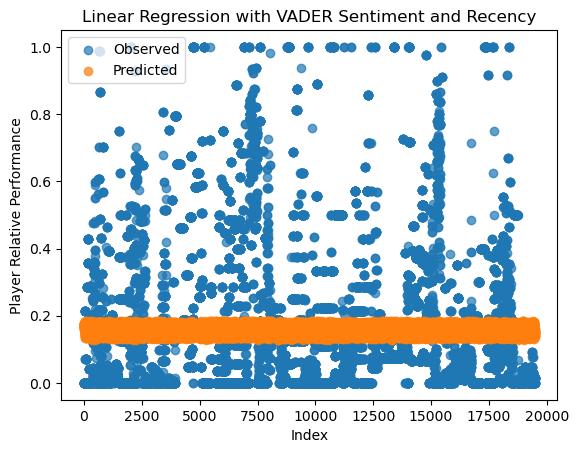

Mean Squared Error: 0.05255361847853805
R Squared Score: -0.009883255500099164


In [402]:
# Measuring performance
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Plotting observed vs predicted values
plt.scatter(range(len(y)), y, label="Observed", alpha=0.7)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", alpha=0.7)
plt.title("Linear Regression with VADER Sentiment and Recency")
plt.xlabel("Index")
plt.ylabel("Player Relative Performance")
plt.legend()
plt.show()

print(f'Mean Squared Error: {mse}')
print(f'R Squared Score: {r2}')

### Model Results

Using the initial dataset to predict Player Relative Performance led to several findings:
- The model is severely underfit
    - This is probably because the current data has virtually no correlation, so the model simply uses the mean of the dataset to make predictions
- Linear regression will most likely not be good for this problem
    - A more complex model will be needed to understand deeper relationships

## Accuracy-based Data Transformations

### Creating interval variable to filter data

In [403]:
absolute_range_var = 0.05

### Creating new df

In [404]:
transformed_player_stat_tweet_df = player_stat_tweet_df.copy()

### Combining compound and polarity features using mean

In [405]:
transformed_player_stat_tweet_df['compound_polarity_avg'] = (transformed_player_stat_tweet_df['compound'] + transformed_player_stat_tweet_df['polarity']) / 2.0

### Remove Player Relative Performances < 0.05

In [406]:
transformed_player_stat_tweet_df = transformed_player_stat_tweet_df[(transformed_player_stat_tweet_df['Player_Relative_Performance'] >= absolute_range_var)]

### Remove highly objective tweets

In [407]:
transformed_player_stat_tweet_df = transformed_player_stat_tweet_df[(transformed_player_stat_tweet_df['subjectivity'] >= absolute_range_var)]

### Remove very neutral tweets

In [408]:
# Not using because accuracy is higher when included
transformed_player_stat_tweet_df = transformed_player_stat_tweet_df[(transformed_player_stat_tweet_df['compound_polarity_avg'] >= absolute_range_var) | (transformed_player_stat_tweet_df['compound_polarity_avg'] <= -absolute_range_var)]

### Analysis of transformed df

In [409]:
transformed_player_stat_tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5856 entries, 39 to 19383
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Player_Name                  5856 non-null   object 
 1   Date                         5856 non-null   object 
 2   Player_Relative_Performance  5856 non-null   float64
 3   is_repost                    5856 non-null   bool   
 4   neg                          5856 non-null   float64
 5   neu                          5856 non-null   float64
 6   pos                          5856 non-null   float64
 7   compound                     5856 non-null   float64
 8   polarity                     5856 non-null   float64
 9   subjectivity                 5856 non-null   float64
 10  Days_Before_Game             5856 non-null   float64
 11  compound_polarity_avg        5856 non-null   float64
dtypes: bool(1), float64(9), object(2)
memory usage: 554.7+ KB


## 4 Attribute Linear Regression

### Creating and training model

In [410]:
# Selecting the attributes
X = transformed_player_stat_tweet_df[["compound_polarity_avg", "Days_Before_Game", "is_repost", "subjectivity"]]
y = transformed_player_stat_tweet_df["Player_Relative_Performance"]

# Creating and training the linear regression model
model = LinearRegression()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model.fit(X_scaled, y)

# Making predictions
y_pred = model.predict(X)

### Visualizing and measuring performance

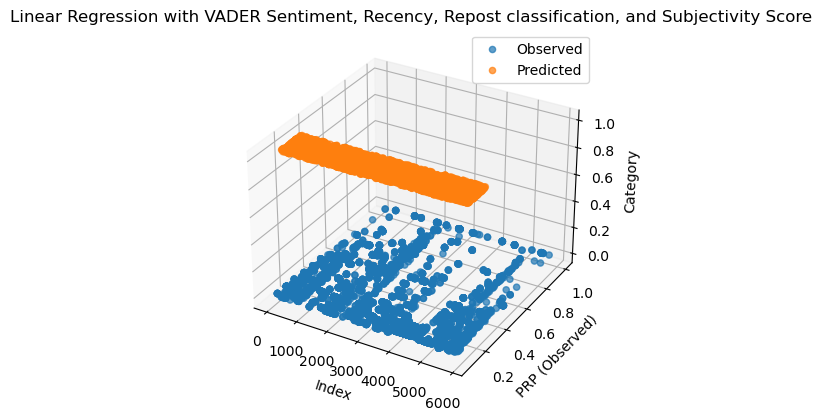

Mean Squared Error: 0.06341069842200732
R Squared Score: -0.12288843870104449


In [411]:
# Measuring performance
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

indices = range(len(y))  # Common index range for data points

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for Observed and Predicted
ax.scatter(indices, y, zs=0, zdir='z', label="Observed", alpha=0.7)
ax.scatter(indices, y_pred, zs=1, zdir='z', label="Predicted", alpha=0.7)

# Customize plot
ax.set_title("Linear Regression with VADER Sentiment, Recency, Repost classification, and Subjectivity Score")
ax.set_xlabel("Index")
ax.set_ylabel("PRP (Observed)")
ax.set_zlabel("Category")  # Distinguishing observed vs predicted
ax.legend()

plt.show()

print(f'Mean Squared Error: {mse}')
print(f'R Squared Score: {r2}')

### Model Results

Using the transformed dataset to predict Player Relative Performance led to several findings:
- The model is fitting slightly better with the transformed dataset and more features
    - There is 1/4 as much data, so it's good that the model isn't underfitting as much
    - Still isn't capturing the outliers and better Player Relative Performances

## Logistic Regression

### Creating and training model

In [ ]:
transformed_player_stat_tweet_df['Performance_Cat'] = pd.cut(transformed_player_stat_tweet_df['Player_Relative_Performance'], 
                               bins=[0,0.25,0.5,0.75,1], 
                               labels=[0,1,2,3],
                               include_lowest=True)

# Convert player name to categorical
transformed_player_stat_tweet_df['Player_Name'] = transformed_player_stat_tweet_df['Player_Name'].astype('category')
transformed_player_stat_tweet_df['Player_Name_cat'] = transformed_player_stat_tweet_df['Player_Name'].cat.codes

# Convert date to a categorical feature (assuming each date corresponds to a particular match)
transformed_player_stat_tweet_df['Date'] = transformed_player_stat_tweet_df['Date'].astype('category')
transformed_player_stat_tweet_df['Date_cat'] = transformed_player_stat_tweet_df['Date'].cat.codes

# is_repost is boolean; convert to int
transformed_player_stat_tweet_df['is_repost'] = transformed_player_stat_tweet_df['is_repost'].astype(int)

# Create day-of-week grouping for Days_Before_Game using modulo 7
transformed_player_stat_tweet_df['Day_Of_Week_Group'] = (transformed_player_stat_tweet_df['Days_Before_Game'] % 7).astype(int)

# This is arbitrary, adjust as needed.
transformed_player_stat_tweet_df['compound_bin'] = pd.cut(transformed_player_stat_tweet_df['compound_polarity_avg'], bins=[-1, 0.2, 0.5, 1], labels=[0, 1, 2])

# Bin subjectivity into ranges (for example, low, medium, high)
transformed_player_stat_tweet_df['subjectivity_bin'] = pd.cut(transformed_player_stat_tweet_df['subjectivity'], bins=[0, 0.33, 0.66, 1], labels=[0, 1, 2])

# For demonstration: Using the requested features - player name, is_repost, and date
# plus the binned features
features = ['Player_Name_cat', 'is_repost', 'Date_cat', 'compound_bin', 'subjectivity_bin', 'Day_Of_Week_Group']

# Convert categorical bins to codes
transformed_player_stat_tweet_df['compound_bin'] = transformed_player_stat_tweet_df['compound_bin'].astype(int)
transformed_player_stat_tweet_df['subjectivity_bin'] = transformed_player_stat_tweet_df['subjectivity_bin'].astype(int)

X = transformed_player_stat_tweet_df[features]
y = transformed_player_stat_tweet_df['Performance_Cat']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model training
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

### Visualizing and measuring performance

Accuracy: 0.3466135458167331
Confusion Matrix:
[[414 117 267 231]
 [116  56 158  87]
 [ 30  17 101  46]
 [ 26  15  38  38]]
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.40      0.51      1029
           1       0.27      0.13      0.18       417
           2       0.18      0.52      0.27       194
           3       0.09      0.32      0.15       117

    accuracy                           0.35      1757
   macro avg       0.31      0.35      0.28      1757
weighted avg       0.50      0.35      0.38      1757



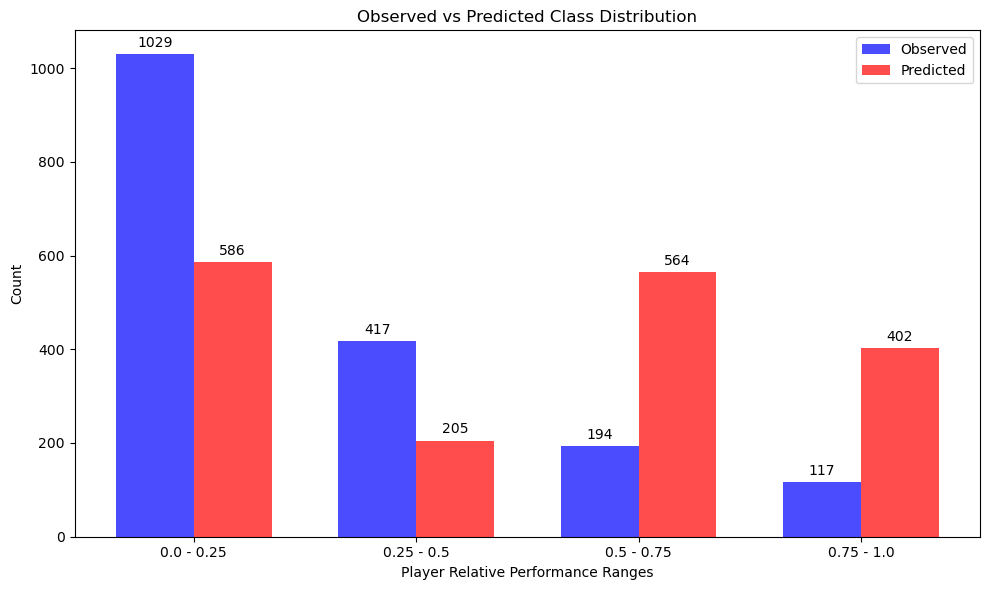

In [ ]:
# Performance metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Get the unique classes and sort them to ensure consistent order
classes = np.unique(np.concatenate((y_test, y_pred)))

# Count frequencies
observed_counts = [(y_test == c).sum() for c in classes]
predicted_counts = [(y_pred == c).sum() for c in classes]

# Define positions for the bars
x = np.arange(len(classes))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, observed_counts, width, label='Observed', alpha=0.7, color='blue')
rects2 = ax.bar(x + width/2, predicted_counts, width, label='Predicted', alpha=0.7, color='red')

# Add labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Count')
ax.set_title('Observed vs Predicted Class Distribution')
ax.set_xticks(x)
ax.set_xticklabels(['0.0 - 0.25', '0.25 - 0.5', '0.5 - 0.75', '0.75 - 1.0'])
ax.set_xlabel('Player Relative Performance Ranges')
ax.legend()

# Optional: Add counts above the bars
def autolabel(rects):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # offset text placement 3 points above bar
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

## Conclusion

The 2 feature linear regression did the worst, and heavily generalized the Player Relative Performance to the point that it predicted everything to be within a small range of the mean. This was to be expected as Player Relative Performance relies on many factors and just using text sentiment with recency was doomed from the start.

The 4 feature linear regression did slightly better, but still generalized heavily and wasn't able to understand the complex relationship between variables that will be needed to make accurate predictions.

The logistic regresion did the best by far, because it used the most features and because it balanced the weight of each class. This meant that even though higher player performances are exponentially more rare and most of the data is for lower player perfromances, the model took this into account and gave more weight to classifications that had less data. This is important to note going forward and applying more complex models, as the data is not evenly distributed. The model might have also benefited from creating the "day of the week". This is because the mental states of players might be consistent across days of the week, as NFL games are consistently on Sunday's.

The main takeways I had from investigating the results from these 3 models was this:
- The relationship between the data is complex and might never be very accurate
- It's important to experiment with different configurations (e.g. using compound over polarity or vice-versa) as certain feature and hyperparameter selections might be more useful or at least insightful
- The data is not evenly distributed across Player Relative Performance